# Simulated Quantum Datasets in QProfiler

Five families of **binary** classification datasets, generated here by exact statevector
simulation, and how to run QProfiler over them. Each cell below generates one family,
and the second half of the notebook ingests the result exactly as
[`example_qprofiler.ipynb`](../QProfiler/example_qprofiler.ipynb) does.

| Family | `type_of_data` | What one row *is* | Label |
|---|---|---|---|
| Ground-state observables | `ground_state` | the Ising couplings $(J_i, h_i)$ | a Pauli observable of the even-sector ground state |
| Time evolution | `time_evolution` | an $n$-bit input string | a sparse observable after $e^{-iH\tau}$ |
| Hamiltonian learning | `hamiltonian_learning` | shot-noisy $\langle Z_i\rangle,\langle X_i\rangle$ after a quench | a property of the hidden $\lambda$ |
| Quantum-circuit labels | `quantum_labels` | circuit parameters $x \in [0,1]^n$ | $\langle Z_0\rangle$ after encoding + Heisenberg evolution |
| Engineered kernel | `engineered_kernel` | $x \in [0,1]^n$ | built to saturate the quantum-advantage bound |

Every family writes the label as the **last column**, which is what QProfiler splits on,
so all five drop into the benchmark with no adapter.

---

```{warning}
**These datasets are simulated, and the sizes here are tiny.** $n = 4$--$6$ qubits and
$N = 60$--$80$ rows keep the notebook to a few minutes; no accuracy printed below is
statistically meaningful, and nothing here is evidence of quantum advantage. The
pre-registered per-family predictions live in
[Simulated quantum datasets](../../quantum_datasets.md) and refer to the runsheet sizes
($n = 6$--$10$, $N = 300$--$400$). Treat this notebook as the *mechanics*: generate,
inspect, ingest, read results.
```

In [1]:
import os

# Pin BLAS to one thread BEFORE qbiocode is imported. Exact diagonalisation here runs
# thousands of small eigendecompositions, and the generators already pin threads around
# their own hot loops -- but scikit-learn and NumPy are imported at package import time,
# and OMP reads this variable once, at load.
os.environ.setdefault("OMP_NUM_THREADS", "1")

import json
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

warnings.simplefilter("ignore")

import qbiocode as qbc
from qbiocode.data_generation import run_selftest

# Two output trees, because the two halves of the corpus need different QProfiler
# settings -- see "Ingesting into QProfiler" below.
XVIEW_ROOT = Path("qdata_out")        # gs, te, hl: physical couplings and measurements
ENCODED_ROOT = Path("qdata_encoded")  # ql, eng:    circuit parameters already in [0, 1]

for root in (XVIEW_ROOT, ENCODED_ROOT):
    shutil.rmtree(root, ignore_errors=True)   # re-runnable: start from nothing

# Printed relative, not resolved: an absolute path here would be baked into the
# stored output and would name whichever machine last executed this notebook.
print("writing to", XVIEW_ROOT, "and", ENCODED_ROOT, "(relative to this notebook)")

writing to qdata_out and qdata_encoded (relative to this notebook)


## Step 0 — verify the simulator before trusting any dataset

The labels are only as good as the simulator that produced them, and a wrong sign or a
transposed bitmask would still yield a perfectly plausible-looking CSV. `run_selftest`
checks seven things against an **independently computed** answer — dense Kronecker
products, a dense Hamiltonian, the analytic short-time expansion of a quench, Parseval's
identity, and Qiskit's own `ZZFeatureMap` — and is the same code the test suite runs in
`tests/test_quantum_data_generation.py::TestThePhysicsIsRight`.

Run it first. If it fails, nothing downstream is worth looking at.

In [2]:
ok, checks = run_selftest()
assert ok, "selftest failed -- do not use data generated by this install"

  ok   Pauli action vs dense kron: max_error=1.388e-16, n_strings=256
  ok   sparse vs dense Hamiltonian: max_error=0.000e+00
  ok   even-sector ground state: residual=5.561e-15, parity=1.000e+00, energy_above_minimum=3.553e-15, gap=4.682e+00
  ok   Walsh-Hadamard transform: round_trip_error=3.331e-16, parseval_error=1.110e-16
  ok   short-time quench expansion: max_error=2.259e-06, t=2.000e-02
  ok   engineered-label bound: s_q=1.000e+00, s_c_over_g2=1.000e+00, g=1.834e+01
  ok   native vs Qiskit ZZFeatureMap: max_infidelity=2.998e-15, max_infidelity_qiskit_map=2.998e-15, max_infidelity_unit_map=2.887e-15, n_comparisons=36
SELFTEST PASS


## Step 1 — generate each family

All five go through the same `qbc.generate_data` entry point as the classical generators.
Two arguments are reinterpreted for the quantum families: **`dim` is the qubit count** and
**`n_samples` is the row count**. Everything else — the label rule, the evolution time, the
shot budget, the encoder — travels in one `quantum_args` dict, so the already-wide
`generate_data` signature does not grow a parameter per family.

Left at their defaults, `dim` and `n_samples` fall back to each family's *runsheet*
configuration rather than the classical defaults, because `dim`'s default reaches 12
qubits: a 4096-dimensional Hilbert space diagonalised once per row.

### 1a. Ground-state observable learning

One row is a disordered transverse-field Ising Hamiltonian, given by its couplings
$J_i \in [0.5, 1.5]$ and fields $h_i \in [0.2, 2.0]$; the features are those $2n-1$
numbers. The label thresholds an observable of the **even-sector** ($\prod_i X_i = +1$)
ground state at its median, so the classes are balanced by construction.

Two label rules, which play opposite roles:

- `sparse` — a random sparse combination of $\mathbb{Z}_2$-even local Paulis. This is the
  *negative control*: the map from couplings to a local observable is smooth, so
  classical models should do well and a quantum model beating them here would be
  surprising rather than encouraging.
- `e2e` — the end-to-end correlator $Z_0 Z_{n-1}$, deliberately **not** in the local pool.

In [3]:
qbc.generate_data(
    type_of_data="ground_state",
    save_path=str(XVIEW_ROOT),
    dim=[6],            # qubits  -> 2n - 1 = 11 features
    n_samples=[80],     # rows
    quantum_args={"label": ["sparse", "e2e"], "kappa": 0.5, "n_terms": 4,
                  "random_state": 0},
)

Generating ground-state observable datasets...


[gs_sparse_n6_k0.5_s0] rows=80 balance=0.500 -> qdata_out


[gs_e2e_n6_k0.5_s0] rows=80 balance=0.500 -> qdata_out
Dataset generation complete.


### 1b. Time evolution — a difficulty ladder, not one dataset

One row is an $n$-bit input string $x$ (so the features are $n$ bits); the label
thresholds $\langle x | e^{iH\tau} O e^{-iH\tau} | x \rangle$ for a fixed sparse
observable $O$ and a fixed non-integrable $H$. The concept class is the one Molteni,
Gyurik and Dunjko study (npj QI **12**, 19, 2026).

`taus` is the ladder: the same Hamiltonian evolved for longer spreads the observable over
more of the lattice, so the Walsh–Hadamard *effective degree* of the labelling function
grows with $\tau$ and every learner should degrade monotonically along it. A model that
does **not** degrade is the audit trigger — it has almost certainly found a shortcut.

Note the guard: inputs are distinct bitstrings drawn without replacement, so
`n_samples` can never exceed $2^n$.

In [4]:
qbc.generate_data(
    type_of_data="time_evolution",
    save_path=str(XVIEW_ROOT),
    dim=[6],            # 6 features; 2**6 = 64 distinct inputs available
    n_samples=[60],
    quantum_args={"taus": [0.25, 1.0, 4.0], "n_terms": 4, "random_state": 0},
)

Generating time-evolution datasets...
[te_n6_s4_seed0_tau0.25] rows=60 balance=0.500 -> qdata_out
[te_n6_s4_seed0_tau1] rows=60 balance=0.500 -> qdata_out
[te_n6_s4_seed0_tau4] rows=60 balance=0.500 -> qdata_out
Dataset generation complete.


### 1c. Hamiltonian learning — the only family with measurement noise on by default

One row is a *measurement record*: $\langle Z_i \rangle$ and $\langle X_i \rangle$ on every
qubit at each time in `times`, taken after a quench of a hidden Hamiltonian
$H(\lambda)$ — so $2n \cdot |\mathrm{times}|$ features. The label is a property of the
hidden $\lambda$ itself, which is the shape of the learning-observables problem in
Huang et al. (Science **376**, 1182, 2022): recover something about the state preparation
from local expectation values.

`shots` binomially resamples every feature, so this is where to study how a finite shot
budget degrades a learner. `shots=0` means exact expectations. The shot count appears in
the dataset name, so a sweep over it does not collide.

In [5]:
qbc.generate_data(
    type_of_data="hamiltonian_learning",
    save_path=str(XVIEW_ROOT),
    dim=[4],            # 2n * len(times) = 8 features
    n_samples=[80],
    quantum_args={"times": [0.5], "shots": 1000, "random_state": 0},
)

Generating Hamiltonian-learning datasets...


[hl_n4_g0.5_shots1000_s0] rows=80 balance=0.500 -> qdata_out
Dataset generation complete.


### 1d. Quantum-circuit labels — data whose label a circuit defined

One row is a parameter vector $x \in [0, 1]^n$; the label thresholds $\langle Z_0 \rangle$
measured after $U_{\mathrm{enc}}(x)$ followed by Heisenberg evolution $e^{-iH\tau}$. The
features *are* the circuit parameters, so this is the closest of the five to "data
generated from a quantum circuit".

Two encodings, and the difference between them is the point:

- `zz` — the `ZZFeatureMap` QProfiler's `qsvc` and `pqk` models both build, though **not
  with the same data map** (see the warning below). A learner can be **aligned** with the
  generator, and alignment is what the family tests.
- `evo` — a different encoding, so every learner is misaligned. This is the control that
  keeps a `zz` result honest.

```{note}
`reps` and `entanglement` do **not** appear in the dataset name. Two runs differing only
in `reps` write to the same file, and the second silently wins. Pass `name=` when
sweeping either one — that is why the documented runsheet has a `ql_zz_pqkdefaults`
dataset. `evo` ignores both knobs entirely.
```

```{warning}
`qsvc` and `pqk` pass **different data maps** to the same `ZZFeatureMap`, so no single
dataset is aligned with both:

| model | data map | generate with |
|---|---|---|
| `qsvc` | Qiskit default, $\phi(x_i)=x_i$, $\phi(x_i,x_j)=(\pi-x_i)(\pi-x_j)$ | `data_map="qiskit"` (default) |
| `pqk` | `unit_coefficient_data_map`, $\phi(x_i)=x_i/2$, $\phi(x_i,x_j)=x_ix_j/2$ | `data_map="unit"` |

Different unitaries, so a different $K_Q$. Both variants are generated below; the
`_dmunit` names are the `pqk`-aligned ones.
```


In [6]:
qbc.generate_data(
    type_of_data="quantum_labels",
    save_path=str(ENCODED_ROOT),
    dim=[4],            # n = 4 features
    n_samples=[60],
    quantum_args={"encoding": ["zz", "evo"], "tau": 1.0,
                  "reps": 2, "entanglement": "linear", "random_state": 0},
)

# The same zz labels against the data map `pqk` actually uses. `evo` has no data map,
# so it is not regenerated -- passing data_map with encoding="evo" would be a no-op
# recorded as None in the metadata.
qbc.generate_data(
    type_of_data="quantum_labels",
    save_path=str(ENCODED_ROOT),
    dim=[4],
    n_samples=[60],
    quantum_args={"encoding": ["zz"], "tau": 1.0, "reps": 2,
                  "entanglement": "linear", "random_state": 0, "data_map": "unit"},
)


Generating quantum-label datasets...
[ql_zz_n4_tau1_s0] rows=60 balance=0.500 -> qdata_encoded
[ql_evo_n4_tau1_s0] rows=60 balance=0.500 -> qdata_encoded
Dataset generation complete.
Generating quantum-label datasets...


[ql_zz_n4_tau1_s0_dmunit] rows=60 balance=0.500 -> qdata_encoded
Dataset generation complete.


### 1e. Engineered kernel — the positive control

Built so a quantum kernel *should* win, by construction rather than by luck. Following
the geometric-difference argument of Huang et al. (Nat. Commun. **12**, 2631, 2021), the
continuous target is chosen to make the quantum model's complexity $s_Q = 1$ while the
classical model's is $s_C = g^2$, where $g$ is the geometric difference. The classical
kernel is not a straw man: 26 RBF bandwidths are scanned and the one giving the
**smallest** $g$ — the strongest classical adversary — is the one kept.

If a quantum method cannot beat classical baselines *here*, the pipeline is misconfigured,
and the first thing to check is whether the learner's encoder matches the one that made
the labels — `reps`, `entanglement`, **and the data map**. The data map is the easiest to
miss and the most damaging: over 40 stratified 70/30 splits on `eng_zz_n4_gq1_s0`,
projected-kernel accuracy is **0.797 ± 0.073** when the map matches and **0.403 ± 0.108**
when it does not. Below chance, because the labels are then anti-aligned with the
encoding's geometry.

```{important}
$g$ is computed for the **continuous** target. The label written to disk is its median
binarisation, and thresholding is not guaranteed to preserve the separation. The metadata
records $g$ under `diagnostics` with exactly that caveat attached. Do not quote $g$ as an
advantage for the classification task.
```

In [7]:
qbc.generate_data(
    type_of_data="engineered_kernel",
    save_path=str(ENCODED_ROOT),
    dim=[4],            # n = 4 features
    n_samples=[60],     # cost is driven by rows here: 26 dense N-by-N eigendecompositions
    quantum_args={"gamma_q": 1.0, "reps": 2, "entanglement": "linear",
                  "random_state": 0},
)

# The qsvc-aligned variant above, and the pqk-aligned one here. Neither is "the"
# engineered dataset: each is a positive control for one arm and a negative control
# for the other.
qbc.generate_data(
    type_of_data="engineered_kernel",
    save_path=str(ENCODED_ROOT),
    dim=[4],
    n_samples=[60],
    quantum_args={"gamma_q": 1.0, "reps": 2, "entanglement": "linear",
                  "random_state": 0, "data_map": "unit"},
)


Generating engineered-kernel datasets...


[eng_zz_n4_gq1_s0] rows=60 balance=0.500 -> qdata_encoded
Dataset generation complete.
Generating engineered-kernel datasets...


[eng_zz_n4_gq1_s0_dmunit] rows=60 balance=0.500 -> qdata_encoded
Dataset generation complete.


## Step 2 — what was written

Each run writes three directories:

| Path | Contents |
|---|---|
| `x_view/<name>.csv` | the **classical description** of the instance, label last. This is the learning problem. |
| `phi_view/<name>.csv` | local Pauli expectations of the simulated state — `gs` and `te` only: a learner handed the right measurements already. |
| `meta/<name>.json` | every parameter, the label rule, the threshold, and per-family diagnostics. |
| `meta/<name>_F.npy` | the continuous pre-threshold target $F$, for regression or for re-thresholding at a different margin. |

`phi_view` is created even by the families that do not use it, so an empty `phi_view/`
directory is expected for `hl`, `ql` and `eng` rather than a sign that something failed.

In [8]:
def summarise(root):
    '''One row per dataset: shape, class balance, and the label rule from the metadata.'''
    rows = []
    for meta_path in sorted((root / "meta").glob("*.json")):
        meta = json.loads(meta_path.read_text())
        name = meta_path.stem
        x = pd.read_csv(root / "x_view" / f"{name}.csv")
        phi_path = root / "phi_view" / f"{name}.csv"
        rows.append({
            "dataset": name,
            "family": meta["family"],
            "rows": len(x),
            "x_features": x.shape[1] - 1,          # the last column is the label
            "phi_features": (pd.read_csv(phi_path).shape[1] - 1) if phi_path.exists() else None,
            "balance": round(meta["class_balance"], 3),
            "last_column": x.columns[-1],
        })
    return pd.DataFrame(rows)


summary = pd.concat([summarise(XVIEW_ROOT), summarise(ENCODED_ROOT)], ignore_index=True)
summary

,dataset,family,rows,x_features,phi_features,balance,last_column
0,gs_e2e_n6_k0.5_s0,gs,80,11,25.0,0.5,label
1,gs_sparse_n6_k0.5_s0,gs,80,11,25.0,0.5,label
2,hl_n4_g0.5_shots1000_s0,hl,80,8,NaN,0.5,label
3,te_n6_s4_seed0_tau0.25,te,60,6,33.0,0.5,label
4,te_n6_s4_seed0_tau1,te,60,6,33.0,0.5,label
5,te_n6_s4_seed0_tau4,te,60,6,33.0,0.5,label
6,eng_zz_n4_gq1_s0,eng,60,4,NaN,0.5,label
7,eng_zz_n4_gq1_s0_dmunit,eng,60,4,NaN,0.5,label
8,ql_evo_n4_tau1_s0,ql,60,4,NaN,0.5,label
9,ql_zz_n4_tau1_s0,ql,60,4,NaN,0.5,label


In [9]:
# The diagnostics are the part worth reading before benchmarking: each family records the
# quantity that says whether the dataset is in the regime it is supposed to be in.
for root in (XVIEW_ROOT, ENCODED_ROOT):
    for meta_path in sorted((root / "meta").glob("*.json")):
        meta = json.loads(meta_path.read_text())
        diag = {k: (round(v, 4) if isinstance(v, float) else v)
                for k, v in meta.get("diagnostics", {}).items()
                if not isinstance(v, (list, dict)) and k != "note"}
        print(f"{meta_path.stem:28s} {diag}")

gs_e2e_n6_k0.5_s0            {'even_sector_gap_min': 2.5816, 'even_sector_gap_median': 3.9384, 'max_eigen_residual': 0.0, 'product_criterion_holdout_acc': 0.825}
gs_sparse_n6_k0.5_s0         {'even_sector_gap_min': 2.2759, 'even_sector_gap_median': 3.7865, 'max_eigen_residual': 0.0}
hl_n4_g0.5_shots1000_s0      {}
te_n6_s4_seed0_tau0.25       {'level_spacing_ratio': 0.4266, 'walsh_effective_degree': 1.1652}
te_n6_s4_seed0_tau1          {'level_spacing_ratio': 0.4266, 'walsh_effective_degree': 1.786}
te_n6_s4_seed0_tau4          {'level_spacing_ratio': 0.4266, 'walsh_effective_degree': 2.6535}
eng_zz_n4_gq1_s0             {'g_continuous': 2.6832, 'g2_continuous': 7.1998}
eng_zz_n4_gq1_s0_dmunit      {'g_continuous': 1.7647, 'g2_continuous': 3.1143}
ql_evo_n4_tau1_s0            {}
ql_zz_n4_tau1_s0             {}
ql_zz_n4_tau1_s0_dmunit      {}


## Step 3 — ingesting into QProfiler

Same three lines as [`example_qprofiler.ipynb`](../QProfiler/example_qprofiler.ipynb) —
load a YAML config, call `profiler.main(config)` — with three settings that are
*requirements* of these datasets rather than preferences:

1. **`folder_path` must name ONE view directory**, `x_view` or `phi_view`, never the
   parent. CSV discovery is a non-recursive `os.listdir` filtered on `endswith('csv')`, so
   pointing it at the `qdata_out/` root finds nothing at all and reports no error.
2. **`embeddings: ['none']`.** The features *are* the physics; compressing 11 couplings to
   3 PCA components discards the structure the label depends on, and `nmf` cannot run on
   the signed features of `phi_view` or `te` at all.
3. **`scaling` differs between the two trees.** `gs`/`te`/`hl` features are physical
   couplings on different scales and no label rule depends on their numeric range, so
   min-max scaling is correct. But `ql`/`eng` draw their features in $[0,1]$ and the
   hidden label rule was evaluated on *exactly those values*: re-scaling per training fold
   moves the inputs away from the encoder that defined the label. Hence two shipped
   configs, `config_qdata_xview.yaml` and `config_qdata_encoded.yaml`, differing in that
   one key.

Both are installed with the package, so they can be loaded rather than copied. On the
command line the same thing is one invocation:

```bash
qprofiler --config-dir=$(python -c "import qbiocode.apps.qprofiler as q, os; \
                                    print(os.path.join(os.path.dirname(q.__file__), 'configs'))") \
          --config-name=config_qdata_xview \
          folder_path=$(pwd)/qdata_out/x_view
```

In [10]:
from qbiocode.apps.qprofiler import qprofiler as profiler

CONFIG_DIR = Path(profiler.__file__).parent / "configs"
print(sorted(p.name for p in CONFIG_DIR.glob("config_qdata*.yaml")))


def load_config(name, **overrides):
    '''Load a shipped config and override a few keys, leaving the file untouched.'''
    config = yaml.safe_load((CONFIG_DIR / f"{name}.yaml").read_text())
    config.update(overrides)
    return config


# Trimmed for notebook runtime. The shipped configs run ten models, iter: 2 and 5-fold CV.
FAST = dict(iter=1, cross_validation=3, n_jobs=4, grid_search=False)

['config_qdata_encoded.yaml', 'config_qdata_xview.yaml']


### Where the output lands

`profiler.main` writes into the **current working directory**, not next to the data:

- `RawDataEvaluation.csv` — one row per dataset of complexity measures, **overwritten**
  on every call.
- `ModelResults.csv` — one row per (dataset, embedding, model, iteration), **appended**
  to on every call.

Because the first is overwritten, two sweeps in one directory would leave only the second
sweep's data-complexity table. The helper below therefore moves both files aside under a
tag after each run, which is also what makes this notebook re-runnable.

> **Two complexity schemas.** `RawDataEvaluation.csv` comes in two generations, and
> `qbiocode.evaluation.dataset_evaluation.detect_complexity_schema` tells them apart:
>
> - **`'legacy'`** — 23 hand-rolled measures, `# Features` and `# Samples` among them.
> - **`'pymfe'`** — the current block, **142 columns**: `Dataset`, 10 native measures
>   kept from the legacy set, 115 `mfe.*` columns from
>   [pyMFE](https://github.com/ealcobaca/pymfe), and 16 `task.*` target-spectrum
>   columns (8 measures, each also as a `_z` score against a label-permutation null).
>
> The rename that matters below: `# Features` and `# Samples` became `mfe.nr_attr` and
> `mfe.nr_inst`. Ten measures survive under their old names — `Intrinsic_Dimension`,
> `Condition number`, `Fisher Discriminant Ratio`, `# Non-zero entries`,
> `# Low variance features`, `Coefficient of Variation %`, `std_co_of_v`,
> `Mean Log Kernel Density`, `Isomap Reconstruction Error` and `Fractal dimension` —
> so the cells below resolve the column names from the schema instead of hardcoding
> either spelling.

In [11]:
def run_profiler(config, tag):
    '''Run one QProfiler sweep and collect its two output CSVs under `tag`.'''
    for stale in ("ModelResults.csv", "RawDataEvaluation.csv"):
        Path(stale).unlink(missing_ok=True)

    profiler.main(config)        # a plain dict: hydra passes it straight through

    results = pd.read_csv("ModelResults.csv")
    evaluation = pd.read_csv("RawDataEvaluation.csv")
    Path("ModelResults.csv").rename(f"ModelResults_{tag}.csv")
    Path("RawDataEvaluation.csv").rename(f"RawDataEvaluation_{tag}.csv")
    return results, evaluation

### Arm A — `gs`, `te`, `hl` on the classical-description view

Classical models only. These three families are about how hard the *classical* map is, and
`gs --label sparse` in particular is the negative control: classical models are expected
to do well.

In [12]:
config_x = load_config(
    "config_qdata_xview",
    folder_path=str((XVIEW_ROOT / "x_view").resolve()),   # absolute: one view directory
    model=["lr", "dt", "rf", "nb", "svc"],
    **FAST,
)
results_x, evaluation_x = run_profiler(config_x, "xview")
results_x[["Dataset", "embeddings", "model", "accuracy", "f1_score", "auc"]]

Processing file: gs_e2e_n6_k0.5_s0.csv


Processing file: gs_sparse_n6_k0.5_s0.csv


Processing file: hl_n4_g0.5_shots1000_s0.csv


Processing file: te_n6_s4_seed0_tau0.25.csv


Processing file: te_n6_s4_seed0_tau1.csv


Processing file: te_n6_s4_seed0_tau4.csv


,Dataset,embeddings,model,accuracy,f1_score,auc
0,gs_e2e_n6_k0.5_s0.csv,none,dt,0.708333,0.707826,0.708333
1,gs_e2e_n6_k0.5_s0.csv,none,lr,0.916667,0.916667,0.951389
2,gs_e2e_n6_k0.5_s0.csv,none,nb,0.833333,0.832168,0.916667
3,gs_e2e_n6_k0.5_s0.csv,none,rf,0.750000,0.748252,0.774306
4,gs_e2e_n6_k0.5_s0.csv,none,svc,0.833333,0.832168,0.937500
5,gs_sparse_n6_k0.5_s0.csv,none,dt,0.875000,0.873016,0.875000
6,gs_sparse_n6_k0.5_s0.csv,none,lr,0.791667,0.788360,0.909722
7,gs_sparse_n6_k0.5_s0.csv,none,nb,0.791667,0.791304,0.944444
8,gs_sparse_n6_k0.5_s0.csv,none,rf,0.833333,0.832168,0.902778
9,gs_sparse_n6_k0.5_s0.csv,none,svc,0.750000,0.733333,0.819444


### Arm B — `ql`, `eng` with the quantum models, unscaled

Here the encoder matters, and it matters in three places at once: `reps`, `entanglement`,
and the **data map**. The shipped `pqk_args` defaults to `reps=4, entanglement='pairwise'`,
which does not match the `reps=2, entanglement='linear'` used above, so it is overridden
below. But overriding those two is *not sufficient*, because `qsvc` and `pqk` build the
`ZZFeatureMap` with different data maps and that is not configurable from the profiler:

| model | where the data map is set | which datasets it is aligned with |
|---|---|---|
| `qsvc` | `compute_qsvc.py` passes no `data_map_func`, so Qiskit's default applies | the plain `ql_zz_*` / `eng_*` names |
| `pqk` | `compute_pqk.py` hardcodes `unit_coefficient_data_map` | the `*_dmunit` names |

So the sweep below is a 2×2: two label sets × two quantum arms, one of which is aligned in
each row. Every dataset is a positive control for exactly one arm and a negative control
for the other, and `ql_evo` is misaligned with both.

```{important}
Read the diagonal, not the column maxima. `pqk` scoring near chance on `eng_zz_n4_gq1_s0`
is the construction working: those labels were built against the *other* data map. The
failure mode this guards against is reading a mismatched cell as a pipeline bug — or, worse,
reading an aligned cell as evidence of advantage. Neither is what these families show.
```

The gate in the next cell makes the pairing explicit before anything is fit, so a
mismatch is reported as a configuration fact rather than discovered as a bad number.

In [13]:
# --- alignment gate -------------------------------------------------------------
# The single most expensive mistake in this arm is running a kernel-aligned family
# against the arm whose data map it was NOT built for: on eng at n=4 that moves PQK
# from 0.797 to 0.403 (40 splits), i.e. from best-in-table to below chance. Nothing
# in the config catches it, because the data map is fixed in the learner's source.
# So state the pairing up front and fail loudly if a label set has no matching arm.
import json as _json

QSVC_DATA_MAP, PQK_DATA_MAP = "qiskit", "unit"        # see compute_qsvc.py / compute_pqk.py
ARM_DATA_MAP = {"qsvc": QSVC_DATA_MAP, "pqk": PQK_DATA_MAP}

encoded_meta = {}
for p in sorted((ENCODED_ROOT / "meta").glob("*.json")):
    if p.stem.endswith("_F"):
        continue
    m = _json.loads(p.read_text())
    if m.get("family") in ("ql", "eng"):
        encoded_meta[p.stem] = m

arms = ["qsvc", "pqk"]
rows = []
for name, m in sorted(encoded_meta.items()):
    dm = m.get("data_map")          # None for 'evo', which has no data map at all
    rows.append({
        "dataset": name,
        "family": m["family"],
        "data_map": dm if dm is not None else "n/a (evo)",
        **{f"{arm} aligned": ("--" if dm is None else "yes" if ARM_DATA_MAP[arm] == dm else "no")
           for arm in arms},
    })
alignment = pd.DataFrame(rows)
print(alignment.to_string(index=False))

# Every data map present must have an arm that matches it, or a whole row of the 2x2
# is unreadable and the aligned/misaligned comparison cannot be made.
present = {r["data_map"] for r in rows} - {"n/a (evo)"}
unmatched = present - set(ARM_DATA_MAP.values())
assert not unmatched, (
    f"datasets generated with data_map={sorted(unmatched)} but no arm uses that map; "
    f"arms available: {ARM_DATA_MAP}"
)
for arm, dm in ARM_DATA_MAP.items():
    if dm not in present:
        print(f"\nNOTE: no dataset was generated with data_map={dm!r}, so {arm!r} has no "
              f"aligned positive control in this sweep and only its negative controls "
              f"will appear.")
print("\nreps/entanglement must match too -- checked against the generated metadata:")
print(pd.DataFrame([{"dataset": n, "reps": m.get("reps"), "entanglement": m.get("entanglement")}
                    for n, m in sorted(encoded_meta.items())]).to_string(index=False))


                dataset family  data_map qsvc aligned pqk aligned
       eng_zz_n4_gq1_s0    eng    qiskit          yes          no
eng_zz_n4_gq1_s0_dmunit    eng      unit           no         yes
      ql_evo_n4_tau1_s0     ql n/a (evo)           --          --
       ql_zz_n4_tau1_s0     ql    qiskit          yes          no
ql_zz_n4_tau1_s0_dmunit     ql      unit           no         yes

reps/entanglement must match too -- checked against the generated metadata:
                dataset  reps entanglement
       eng_zz_n4_gq1_s0     2       linear
eng_zz_n4_gq1_s0_dmunit     2       linear
      ql_evo_n4_tau1_s0     2       linear
       ql_zz_n4_tau1_s0     2       linear
ql_zz_n4_tau1_s0_dmunit     2       linear


In [14]:
config_e = load_config(
    "config_qdata_encoded",
    folder_path=str((ENCODED_ROOT / "x_view").resolve()),
    model=["lr", "rf", "svc", "qsvc", "pqk"],
    # Align PQK's reps/entanglement with the feature map that made the labels. Its data
    # map is NOT settable here -- compute_pqk hardcodes unit_coefficient_data_map -- which
    # is why the *_dmunit datasets exist. See the gate above.
    pqk_args={"encoding": "ZZ", "entanglement": "linear", "primitive": "estimator",
              "reps": 2},
    **FAST,
)
print("scaling:", config_e["scaling"], "| embeddings:", config_e["embeddings"])
results_e, evaluation_e = run_profiler(config_e, "encoded")
results_e[["Dataset", "embeddings", "model", "accuracy", "f1_score", "auc"]]

scaling: False | embeddings: ['none']
Processing file: eng_zz_n4_gq1_s0.csv


Processing file: eng_zz_n4_gq1_s0_dmunit.csv


Processing file: ql_evo_n4_tau1_s0.csv


Processing file: ql_zz_n4_tau1_s0.csv


Processing file: ql_zz_n4_tau1_s0_dmunit.csv


,Dataset,embeddings,model,accuracy,f1_score,auc
0,eng_zz_n4_gq1_s0.csv,none,lr,0.444444,0.437500,0.370370
1,eng_zz_n4_gq1_s0.csv,none,pqk,0.444444,0.437500,0.320988
2,eng_zz_n4_gq1_s0.csv,none,qsvc,0.500000,0.485714,0.518519
3,eng_zz_n4_gq1_s0.csv,none,rf,0.388889,0.386997,0.327160
4,eng_zz_n4_gq1_s0.csv,none,svc,0.444444,0.444444,0.345679
5,eng_zz_n4_gq1_s0_dmunit.csv,none,lr,0.833333,0.832817,0.851852
6,eng_zz_n4_gq1_s0_dmunit.csv,none,pqk,0.944444,0.944272,0.987654
7,eng_zz_n4_gq1_s0_dmunit.csv,none,qsvc,0.611111,0.600000,0.765432
8,eng_zz_n4_gq1_s0_dmunit.csv,none,rf,0.888889,0.888889,0.907407
9,eng_zz_n4_gq1_s0_dmunit.csv,none,svc,0.833333,0.832817,0.851852


## Step 4 — read the results

First a consistency check that costs nothing and catches the most common ingestion
mistake. With `embeddings: ['none']` the features reach the models untouched, so
QProfiler's reported feature count must equal the feature count generated — which for
these families is a *qubit* count:

| Family | `x_view` features | `phi_view` features |
|---|---|---|
| `gs` | $2n - 1$ | $5n - 5$ |
| `te` | $n$ | $6n - 3$ |
| `hl` | $2n \cdot |\mathrm{times}|$ | — |
| `ql`, `eng` | $n$ | — |

If they disagree, an embedding is on, `index_col` is wrong, or `folder_path` points
somewhere unexpected.

The column holding that count depends on the schema (`mfe.nr_attr` on the current
pyMFE block, `# Features` on a pre-pyMFE table), so the next cell asks
`detect_complexity_schema` rather than assuming one.

In [15]:
from qbiocode.evaluation.dataset_evaluation import (
    SAMPLE_COUNT_COLUMN,
    detect_complexity_schema,
)

evaluation = pd.concat([evaluation_x.assign(view="x_view (gs/te/hl)"),
                        evaluation_e.assign(view="x_view (ql/eng)")], ignore_index=True)

# Resolve the two columns this check needs from whichever schema the table is in, so a
# results file written before the pyMFE change still works here.
N_FEATURE_COLUMN = {"legacy": "# Features", "pymfe": "mfe.nr_attr"}
schema, feature_columns = detect_complexity_schema(evaluation)
n_feat = N_FEATURE_COLUMN[schema]
n_samp = SAMPLE_COUNT_COLUMN[schema]
print(f"complexity schema : {schema!r}")
print(f"complexity columns: {len(feature_columns)}  (+ 'Dataset' = {evaluation.shape[1]} total)")
print(f"feature count in  : {n_feat!r}        sample count in: {n_samp!r}")

# QProfiler reports the CSV file name, extension included, so strip it before matching.
check = evaluation[["Dataset", n_feat, n_samp, "view"]].copy()
check["dataset"] = check["Dataset"].str.removesuffix(".csv")
check = check.merge(summary[["dataset", "x_features"]], on="dataset", how="left")
check["matches generated"] = check[n_feat] == check["x_features"]
assert check["matches generated"].all(), "feature count changed between generation and profiling"
check.drop(columns="Dataset")

complexity schema : 'pymfe'
complexity columns: 141  (+ 'Dataset' = 143 total)
feature count in  : 'mfe.nr_attr'        sample count in: 'mfe.nr_inst'


,mfe.nr_attr,mfe.nr_inst,view,dataset,x_features,matches generated
0,11.0,80.0,x_view (gs/te/hl),gs_e2e_n6_k0.5_s0,11,True
1,11.0,80.0,x_view (gs/te/hl),gs_sparse_n6_k0.5_s0,11,True
2,8.0,80.0,x_view (gs/te/hl),hl_n4_g0.5_shots1000_s0,8,True
3,6.0,60.0,x_view (gs/te/hl),te_n6_s4_seed0_tau0.25,6,True
4,6.0,60.0,x_view (gs/te/hl),te_n6_s4_seed0_tau1,6,True
5,6.0,60.0,x_view (gs/te/hl),te_n6_s4_seed0_tau4,6,True
6,4.0,60.0,x_view (ql/eng),eng_zz_n4_gq1_s0,4,True
7,4.0,60.0,x_view (ql/eng),eng_zz_n4_gq1_s0_dmunit,4,True
8,4.0,60.0,x_view (ql/eng),ql_evo_n4_tau1_s0,4,True
9,4.0,60.0,x_view (ql/eng),ql_zz_n4_tau1_s0,4,True


In [16]:
# The data-complexity measures explain a lot of the accuracy ordering on their own.
# These ten survived the pyMFE change under their original names, so this selection reads
# the same on either schema.
evaluation[["Dataset", n_feat, "Intrinsic_Dimension", "Fractal dimension",
            "Fisher Discriminant Ratio"]].round(3)

,Dataset,mfe.nr_attr,Intrinsic_Dimension,Fractal dimension,Fisher Discriminant Ratio
0,gs_e2e_n6_k0.5_s0.csv,11.0,11,1.997,0.079
1,gs_sparse_n6_k0.5_s0.csv,11.0,11,1.997,0.097
2,hl_n4_g0.5_shots1000_s0.csv,8.0,6,1.996,0.174
3,te_n6_s4_seed0_tau0.25.csv,6.0,6,1.993,0.211
4,te_n6_s4_seed0_tau1.csv,6.0,6,1.993,0.039
5,te_n6_s4_seed0_tau4.csv,6.0,6,1.993,0.056
6,eng_zz_n4_gq1_s0.csv,4.0,4,1.990,0.008
7,eng_zz_n4_gq1_s0_dmunit.csv,4.0,4,1.990,0.201
8,ql_evo_n4_tau1_s0.csv,4.0,4,1.990,0.137
9,ql_zz_n4_tau1_s0.csv,4.0,4,1.990,0.020


In [17]:
# New on this branch: the target spectrum, which asks where y sits in the geometry of X
# rather than measuring X alone. `_z` is a z-score against a label-permutation null, so it
# reads as "how far from a random labelling of this same data" -- which is exactly the
# question these families are built to pose. `eng` labels are engineered to be hostile to a
# classical kernel, so a low task.purity_auc_z there is the construction working, not a bug.
task_cols = [c for c in evaluation.columns if c.startswith("task.") and c.endswith("_z")]
if task_cols:
    display(evaluation[["Dataset", "task.purity_auc_z", "task.graph_dirichlet_z",
                        "task.pca_tail_signal_z"]].round(3))
else:
    print("No task.* columns: this table predates the target-spectrum block.")

,Dataset,task.purity_auc_z,task.graph_dirichlet_z,task.pca_tail_signal_z
0,gs_e2e_n6_k0.5_s0.csv,1.823,-1.773,1.006
1,gs_sparse_n6_k0.5_s0.csv,3.434,-3.197,0.942
2,hl_n4_g0.5_shots1000_s0.csv,4.870,-5.059,-1.637
3,te_n6_s4_seed0_tau0.25.csv,6.905,-7.138,0.000
4,te_n6_s4_seed0_tau1.csv,4.089,-2.023,0.000
5,te_n6_s4_seed0_tau4.csv,1.413,-1.021,0.000
6,eng_zz_n4_gq1_s0.csv,-1.821,1.725,0.000
7,eng_zz_n4_gq1_s0_dmunit.csv,4.566,-4.310,0.000
8,ql_evo_n4_tau1_s0.csv,6.100,-6.455,0.000
9,ql_zz_n4_tau1_s0.csv,0.466,-0.867,0.000


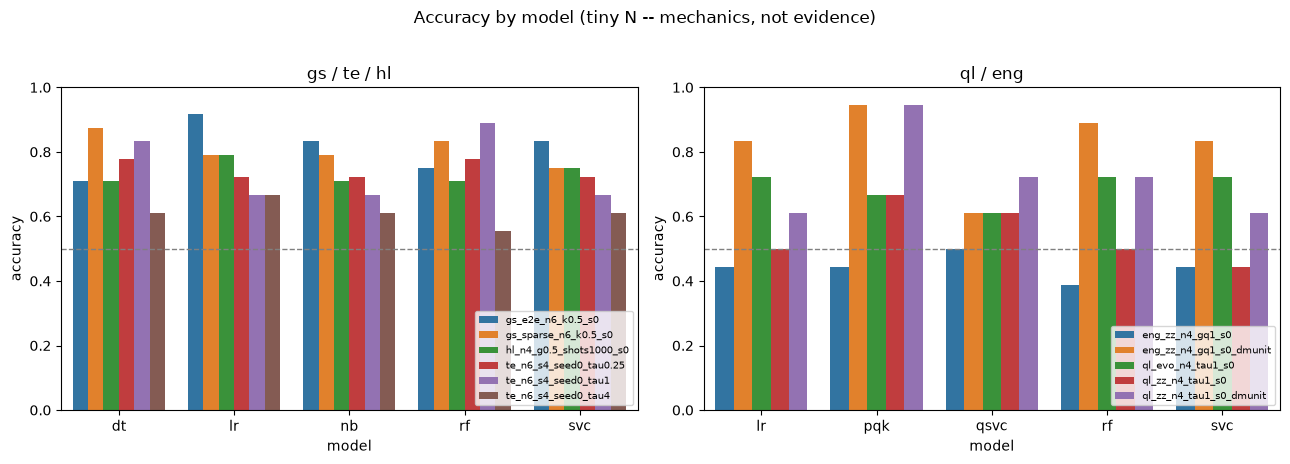

In [18]:
results = pd.concat([results_x.assign(arm="gs / te / hl"),
                     results_e.assign(arm="ql / eng")], ignore_index=True)
results["dataset"] = results["Dataset"].str.removesuffix(".csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (arm, group) in zip(axes, results.groupby("arm")):
    sns.barplot(data=group, x="model", y="accuracy", hue="dataset", ax=ax)
    ax.axhline(0.5, color="grey", ls="--", lw=1)     # the balanced-class baseline
    ax.set_title(arm)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc="lower right")
fig.suptitle("Accuracy by model (tiny N -- mechanics, not evidence)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# The te ladder is the one result whose *shape* is predicted in advance: accuracy should
# fall monotonically as tau grows, because the effective degree of the labelling function
# grows with it. At N = 60 this is far too noisy to confirm -- it is shown as the shape to
# look for at the runsheet sizes.
ladder = results_x[results_x["Dataset"].str.startswith("te_")].copy()
ladder["tau"] = ladder["Dataset"].str.extract(r"tau([\d.]+)\.csv").astype(float)
ladder.pivot_table(index="tau", columns="model", values="accuracy").round(3)

model,dt,lr,nb,rf,svc
tau,,,,,
0.25,0.778,0.722,0.722,0.778,0.722
1.00,0.833,0.667,0.667,0.889,0.667
4.00,0.611,0.667,0.611,0.556,0.611


## What to expect at full size, and what not to claim

Each family exists to answer one question, and each has an **audit trigger** — a result
that means the pipeline is wrong rather than that something was discovered:

| Family | Role | Expected | Audit trigger |
|---|---|---|---|
| `gs --label sparse` | negative control | classical models do well | a quantum model winning clearly |
| `gs --label e2e` | harder classical map | the product criterion tracks it | classical accuracy at chance |
| `te` | difficulty ladder | accuracy falls monotonically in $\tau$ | flat or non-monotonic in $\tau$ |
| `hl` | shot-noise robustness | accuracy falls as `shots` falls | no dependence on `shots` |
| `ql --encoding zz` | encoder alignment | aligned kernel > misaligned | `evo` matching `zz` |
| `ql --encoding evo` | alignment control | all learners mediocre | any learner excelling |
| `eng` | positive control | quantum kernel wins | it does not — check the encoder first |

### Non-claims

- **None of this is evidence of quantum advantage.** The data was produced by a classical
  simulator; a quantum kernel winning on `eng` shows the construction worked, not that
  quantum hardware would help on real data.
- The **`eng` bound is for the continuous target**, not the binarised label written to
  disk. Thresholding may not preserve the separation.
- `evo` is **this package's own encoding definition**, not the E3 encoding of Huang et al.
- $n \le 12$ qubits is a regime where classical simulation is easy *by definition* — that
  is what makes the labels computable at all.
- The `te` ladder is a statement about **effective degree**, not about hardness in any
  complexity-theoretic sense.
- `phi_view` hands the learner measurements a real experiment would have to pay for. It is
  an upper bound on what a measurement-based learner could do, not a realistic setting.
- The label rule is a **median threshold**, so 50% accuracy is exactly chance for every
  dataset here and balance is never evidence of anything.

### See also

- [Simulated quantum datasets](../../quantum_datasets.md) — the full runsheet, the
  verification table, and the layout reference.
- [`example_qprofiler.ipynb`](../QProfiler/example_qprofiler.ipynb) — the same QProfiler
  workflow on classical artificial data, with correlation analysis.
- `qdata-gen selftest` — the seven physics checks from Step 0, on the command line.